Current folder:
/Users/nikos/Documents/Master/Thesis/Software/Conformal_Prediction_Classification/Anomaly_detection

Files/folders here:
['.DS_Store', 'Anomaly_Detection.ipynb', '__pycache__', '.ipynb_checkpoints']
q_hat: 5.17522293761707
Detected anomalies: 998
ROC-AUC: 0.6322602929628869
PR-AUC: 0.09895739135843182
              precision    recall  f1-score   support

           0     0.9492    0.9544    0.9518     18897
           1     0.1373    0.1242    0.1304      1103

    accuracy                         0.9086     20000
   macro avg     0.5432    0.5393    0.5411     20000
weighted avg     0.9044    0.9086    0.9065     20000



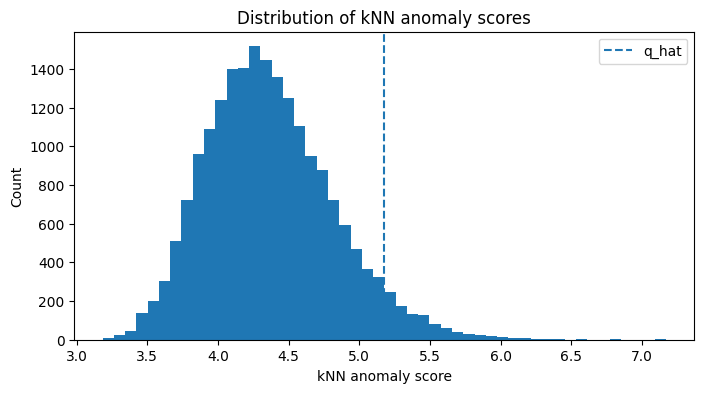

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.linear_model import LogisticRegression

sys.path.append(os.path.abspath(".."))

from CP.classifier import SplitConformalClassifier
from CP.scores import ClassificationScores


print("Current folder:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

# Create data
X, y = make_classification(n_samples=20000, n_features=30, n_informative=10, n_redundant=5, n_classes=2, weights=[0.95, 0.05], 
                           random_state=42)

X = StandardScaler().fit_transform(X)

# kNN scores
k = 10
nbrs = NearestNeighbors(n_neighbors=k + 1, n_jobs=-1)
nbrs.fit(X)

distances, _ = nbrs.kneighbors(X)
scores = distances[:, k]

# Use YOUR existing class only for q_hat
cp = SplitConformalClassifier( model=LogisticRegression(), alpha=0.05)

q_hat = cp._conformal_quantile(scores)

# Predict
y_pred = np.where(scores <= q_hat, 0, 1)

print("q_hat:", q_hat)
print("Detected anomalies:", np.sum(y_pred == 1))
print("ROC-AUC:", roc_auc_score(y, scores))
print("PR-AUC:", average_precision_score(y, scores))
print(classification_report(y, y_pred, digits=4))

# Plot
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=50)
plt.axvline(q_hat, linestyle="--", label="q_hat")
plt.xlabel("kNN anomaly score")
plt.ylabel("Count")
plt.title("Distribution of kNN anomaly scores")
plt.legend()
plt.show()